### Cell1 : Imports and project paths

In [1]:
from pathlib import Path
import os
import io
import time
import json
import yaml
import base64
import socket
import shutil
import random
import tempfile
import subprocess
import gc
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import requests
import websocket
import torch
from ultralytics import YOLO

PROJECT_DIR = Path.cwd()

for p in [PROJECT_DIR, PROJECT_DIR.parent, PROJECT_DIR.parent.parent]:
    if (p / "data").exists() and (p / "website.html").exists():
        PROJECT_DIR = p
        break
else:
    raise FileNotFoundError("Project root not found. Expected 'data/' and 'website.html'.")

DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
HTML_PATH = PROJECT_DIR / "website.html"

OUTPUT_DIR = PROJECT_DIR / "_generated"

YOLO_DATASET_DIR = OUTPUT_DIR / "captcha_yolo_split_data"
RUNS_DIR = OUTPUT_DIR / "runs" / "captcha_yolo_split_data"
REPORT_DIR = OUTPUT_DIR / "report_outputs" / "split_data_experiment"

for d in [OUTPUT_DIR, RUNS_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
assert TRAIN_DIR.exists(), f"TRAIN_DIR not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"TEST_DIR not found: {TEST_DIR}"
assert HTML_PATH.exists(), f"website.html not found: {HTML_PATH}"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PROJECT_DIR:", PROJECT_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("YOLO_DATASET_DIR:", YOLO_DATASET_DIR)
print("RUNS_DIR:", RUNS_DIR)

PROJECT_DIR: C:\Users\Masih\PycharmProjects\captcha
TRAIN_DIR: C:\Users\Masih\PycharmProjects\captcha\data\train
TEST_DIR: C:\Users\Masih\PycharmProjects\captcha\data\test
YOLO_DATASET_DIR: C:\Users\Masih\PycharmProjects\captcha\_generated\captcha_yolo_split_data
RUNS_DIR: C:\Users\Masih\PycharmProjects\captcha\_generated\runs\captcha_yolo_split_data


### Cell2 : Classes and dataset counts

In [2]:
PNG_EXT = ".png"

CLASS_SPECS = [
    ("Bicycle", "Bicycle"),
    ("Bridge", "Bridge"),
    ("Bus", "Bus"),
    ("Car", "Car"),
    ("Cross", "Crosswalk"),
    ("Hydrant", "Hydrant"),
    ("Motorcycle", "Motorcycle"),
    ("Stair", "Stair"),
    ("Tlight", "Traffic Light"),
]

all_class_names = [x[0] for x in CLASS_SPECS]
source_folder_by_class = dict(CLASS_SPECS)
class_to_id = {name: i for i, name in enumerate(all_class_names)}
id_to_class = {i: name for name, i in class_to_id.items()}

available = {p.name for d in [TRAIN_DIR, TEST_DIR] for p in d.iterdir() if p.is_dir()}
missing = [folder for _, folder in CLASS_SPECS if folder not in available]

if missing:
    raise FileNotFoundError(f"Missing class folders: {missing}")


def count_png(split_dir, folder):
    return len(list((split_dir / folder).rglob(f"*{PNG_EXT}")))


df_class_counts = pd.DataFrame([
    {
        "class_name": cls,
        "source_folder": folder,
        "train_count": count_png(TRAIN_DIR, folder),
        "test_count": count_png(TEST_DIR, folder),
    }
    for cls, folder in CLASS_SPECS
])

df_class_counts["total_count"] = df_class_counts["train_count"] + df_class_counts["test_count"]

df_class_counts

,class_name,source_folder,train_count,test_count,total_count
0,Bicycle,Bicycle,790,156,946
1,Bridge,Bridge,509,107,616
2,Bus,Bus,1209,242,1451
3,Car,Car,2856,712,3568
4,Cross,Crosswalk,1258,248,1506
5,Hydrant,Hydrant,952,190,1142
6,Motorcycle,Motorcycle,80,16,96
7,Stair,Stair,179,42,221
8,Tlight,Traffic Light,783,158,941


### Cell3 : Build YOLO train test dataset

In [3]:
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

for split in ["train", "test"]:
    (YOLO_DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def safe_name(x):
    return str(x).replace(" ", "_").replace("/", "_").replace("\\", "_")


def collect_items(split_dir, split_name):
    items = []
    for cls in all_class_names:
        folder = source_folder_by_class[cls]
        for img in sorted((split_dir / folder).rglob("*.png")):
            items.append((img, split_name, cls, class_to_id[cls], folder))
    return items


items = collect_items(TRAIN_DIR, "train") + collect_items(TEST_DIR, "test")
rows = []

for i, (src, split, cls, cid, folder) in enumerate(items):
    stem = f"{split}_{safe_name(cls)}_{i:06d}"
    dst_img = YOLO_DATASET_DIR / "images" / split / f"{stem}.png"
    dst_lbl = YOLO_DATASET_DIR / "labels" / split / f"{stem}.txt"
    shutil.copy2(src, dst_img)
    dst_lbl.write_text(f"{cid} 0.5 0.5 1.0 1.0\n", encoding="utf-8")
    rows.append({
        "split": split,
        "class_name": cls,
        "source_folder": folder,
        "image_path": str(dst_img),
        "label_path": str(dst_lbl),
        "class_id": cid
    })

df_yolo_records = pd.DataFrame(rows)

data_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()).replace("\\", "/"),
    "train": "images/train",
    "val": "images/train",
    "test": "images/test",
    "nc": len(all_class_names),
    "names": all_class_names
}

yaml_path = YOLO_DATASET_DIR / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

df_split_counts = (
    df_yolo_records
    .groupby(["split", "class_name"])
    .size()
    .unstack(0, fill_value=0)
    .reindex(all_class_names)
    .reset_index()
)

display(df_split_counts)
print("data.yaml:", yaml_path)

split,class_name,test,train
0,Bicycle,156,790
1,Bridge,107,509
2,Bus,242,1209
3,Car,712,2856
4,Cross,248,1258
5,Hydrant,190,952
6,Motorcycle,16,80
7,Stair,42,179
8,Tlight,158,783


data.yaml: C:\Users\Masih\PycharmProjects\captcha\_generated\captcha_yolo_split_data\data.yaml


### Cell4 : Verify and preview YOLO dataset

,split,images,labels
0,train,8616,8616
1,test,1871,1871


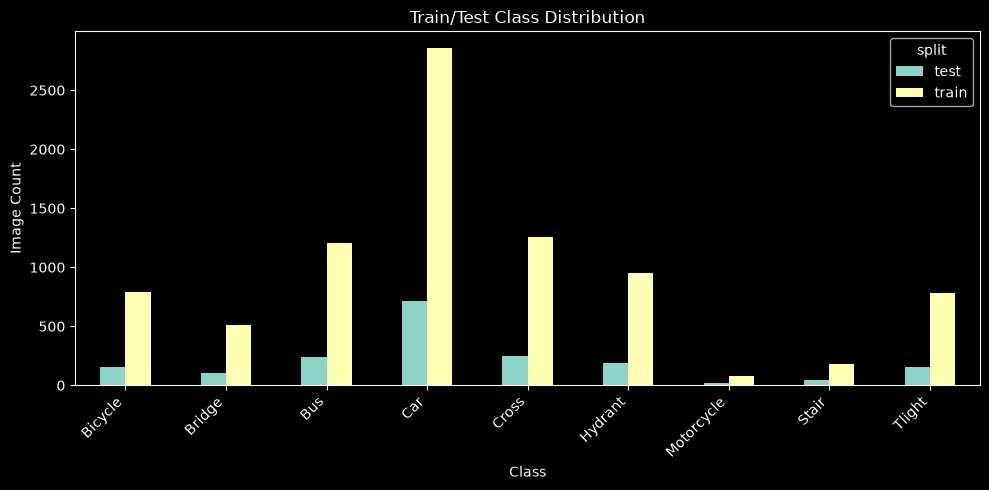

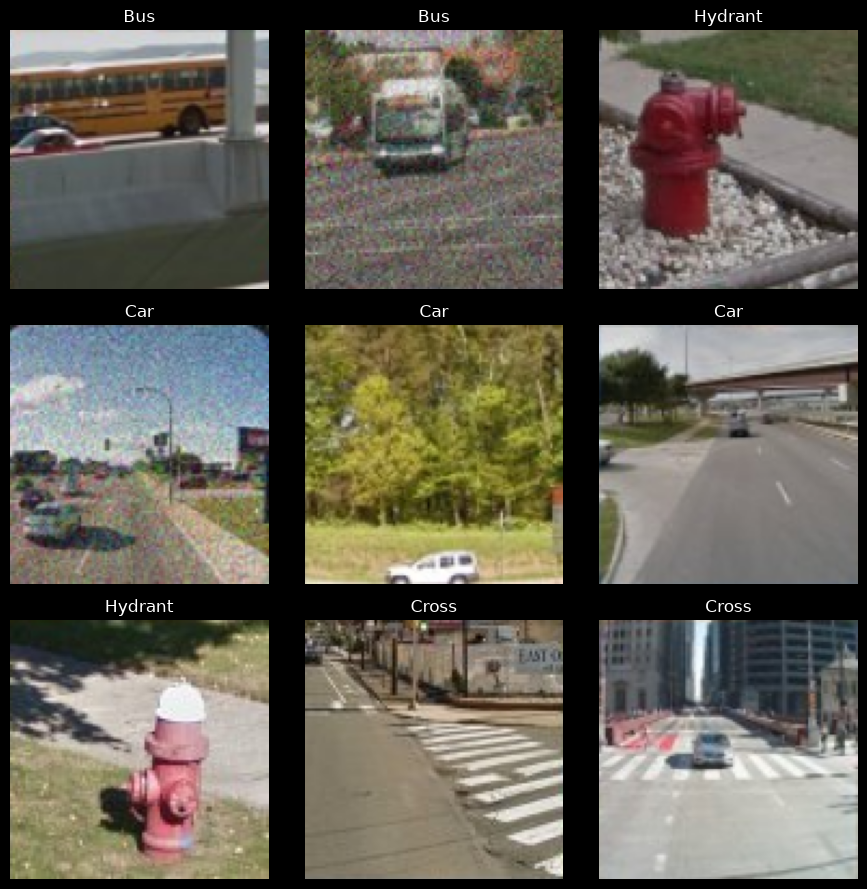

split,test,train
class_name,,
Bicycle,156,790
Bridge,107,509
Bus,242,1209
Car,712,2856
Cross,248,1258
Hydrant,190,952
Motorcycle,16,80
Stair,42,179
Tlight,158,783


In [4]:
verify_rows = []

for split in ["train", "test"]:
    img_dir = YOLO_DATASET_DIR / "images" / split
    lbl_dir = YOLO_DATASET_DIR / "labels" / split

    imgs = sorted(img_dir.glob("*.png"))
    lbls = sorted(lbl_dir.glob("*.txt"))

    assert len(imgs) > 0, f"No images in {split}"
    assert len(lbls) > 0, f"No labels in {split}"
    assert len(imgs) == len(lbls), f"Image/label mismatch in {split}"

    verify_rows.append({
        "split": split,
        "images": len(imgs),
        "labels": len(lbls)
    })

df_verify_dataset = pd.DataFrame(verify_rows)
display(df_verify_dataset)

pivot_counts = (
    df_yolo_records
    .groupby(["class_name", "split"])
    .size()
    .unstack("split", fill_value=0)
    .reindex(all_class_names)
)

pivot_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Train/Test Class Distribution")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sample_df = (
    df_yolo_records[df_yolo_records["split"].eq("train")]
    .sample(min(9, len(df_yolo_records[df_yolo_records["split"].eq("train")])), random_state=SEED)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 9))

for i, row in sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row["class_name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

pivot_counts

### Cell5 : Oversample train only

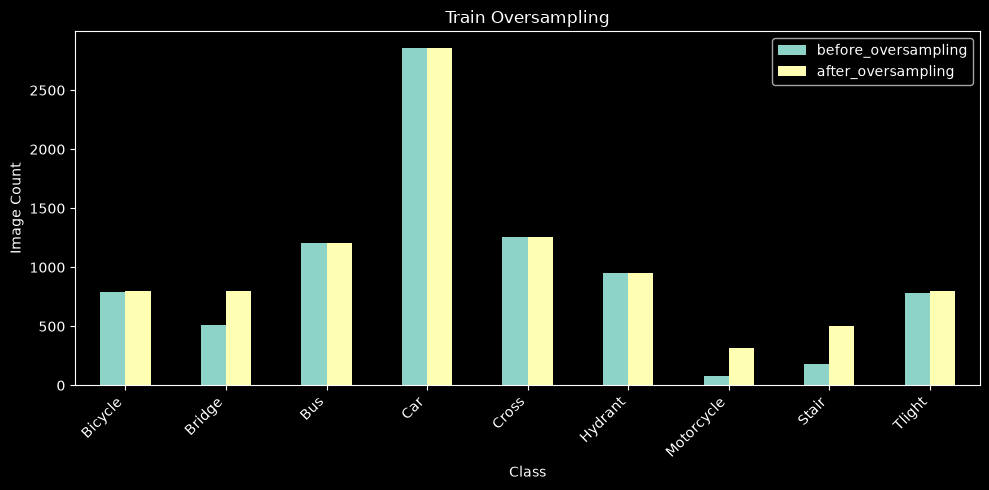

,class_name,before_oversampling,after_oversampling
0,Bicycle,790,800
1,Bridge,509,800
2,Bus,1209,1209
3,Car,2856,2856
4,Cross,1258,1258
5,Hydrant,952,952
6,Motorcycle,80,320
7,Stair,179,500
8,Tlight,783,800


In [5]:
img_dir = YOLO_DATASET_DIR / "images" / "train"
lbl_dir = YOLO_DATASET_DIR / "labels" / "train"

for p in list(img_dir.glob("*_os_*")) + list(lbl_dir.glob("*_os_*")):
    p.unlink()


def train_counts():
    names = []
    for lbl in lbl_dir.glob("*.txt"):
        cid = int(lbl.read_text(encoding="utf-8").split()[0])
        names.append(id_to_class[cid])
    return pd.Series(names).value_counts().reindex(all_class_names, fill_value=0)


def target_count(n):
    if n < 100:
        return min(n * 4, 320)
    if n < 300:
        return 500
    if n < 800:
        return 800
    return n


before_os = train_counts()

for cls in all_class_names:
    cid = class_to_id[cls]
    labels = [p for p in lbl_dir.glob("*.txt") if int(p.read_text(encoding="utf-8").split()[0]) == cid]
    target = target_count(len(labels))
    need = max(0, target - len(labels))

    for i, src_lbl in enumerate(random.choices(labels, k=need)):
        src_img = next(img_dir.glob(f"{src_lbl.stem}.*"))
        new_stem = f"{src_lbl.stem}_os_{i:06d}"
        shutil.copy2(src_lbl, lbl_dir / f"{new_stem}.txt")
        shutil.copy2(src_img, img_dir / f"{new_stem}{src_img.suffix}")

after_os = train_counts()

df_os_compare = pd.DataFrame({
    "class_name": all_class_names,
    "before_oversampling": before_os.values,
    "after_oversampling": after_os.values
})

df_os_compare.plot(x="class_name", y=["before_oversampling", "after_oversampling"], kind="bar", figsize=(10, 5))
plt.title("Train Oversampling")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df_os_compare

### Cell6 : Train YOLO model

In [6]:
assert yaml_path.exists(), f"data.yaml not found: {yaml_path}"

os.environ["WANDB_DISABLED"] = "true"

for v in ["model", "best_model"]:
    globals().pop(v, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 8
EPOCHS = 120
IMGSZ = 512
BATCH = 16 if torch.cuda.is_available() else 2
AMP = torch.cuda.is_available()

base_model_path = PROJECT_DIR / "yolo11s.pt"
BASE_MODEL = str(base_model_path) if base_model_path.exists() else "yolo11s.pt"

run_timestamp = time.strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"split_yolo11s_img{IMGSZ}_e{EPOCHS}_{run_timestamp}"

model = YOLO(BASE_MODEL)

train_results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    cache=False,
    amp=AMP,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=False,
    pretrained=True,
    patience=50,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    seed=SEED,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=0,
    hsv_h=0.006,
    hsv_s=0.12,
    hsv_v=0.10,
    degrees=1.0,
    translate=0.01,
    scale=0.04,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.0,
    box=3.0,
    cls=1.6,
    dfl=0.8,
    plots=True,
    verbose=True
)

RUN_DIR = Path(train_results.save_dir)
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"
LAST_MODEL_PATH = RUN_DIR / "weights" / "last.pt"

assert BEST_MODEL_PATH.exists(), f"Best model not found: {BEST_MODEL_PATH}"

del model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

best_model = YOLO(str(BEST_MODEL_PATH))

print("Best model path:", BEST_MODEL_PATH)

BEST_MODEL_PATH

New https://pypi.org/project/ultralytics/8.4.80 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.78  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=3.0, cache=False, cfg=None, classes=None, close_mosaic=0, cls=1.6, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Masih\PycharmProjects\captcha\_generated\captcha_yolo_split_data\data.yaml, degrees=1.0, deterministic=True, device=0, dfl=0.8, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.006, hsv_s=0.12, hsv_v=0.1, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max

WindowsPath('C:/Users/Masih/PycharmProjects/captcha/_generated/runs/captcha_yolo_split_data/split_yolo11s_img512_e120_20260627_170601/weights/best.pt')

### Cell7 : Evaluate on test set

Ultralytics 8.4.78  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 101 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 4.60.4 MB/s, size: 39.7 KB)
val: Scanning C:\Users\Masih\PycharmProjects\captcha\_generated\captcha_yolo_split_data\labels\test... 1871 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1871/1871 589.8it/s 3.2s0.1s
val: New cache created: C:\Users\Masih\PycharmProjects\captcha\_generated\captcha_yolo_split_data\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 117/117 8.9it/s 13.1s0.1s
                   all       1871       1871      0.932      0.928      0.955       0.86
               Bicycle        156        156      0.956      0.987      0.988       0.89
                Bridge        107        107      0.893      0.933      0.951      0.856
                   Bus       

,test_images,correct,wrong,accuracy
0,1871,1764,107,0.942811


,precision,recall,f1-score,support
Bicycle,0.951220,1.000000,0.975000,156.000000
Bridge,0.851240,0.962617,0.903509,107.000000
Bus,0.895911,0.995868,0.943249,242.000000
Car,0.985827,0.879213,0.929473,712.000000
Cross,0.913858,0.983871,0.947573,248.000000
Hydrant,0.994764,1.000000,0.997375,190.000000
Motorcycle,0.888889,1.000000,0.941176,16.000000
Stair,0.941176,0.761905,0.842105,42.000000
Tlight,0.906977,0.987342,0.945455,158.000000
accuracy,0.942811,0.942811,0.942811,0.942811


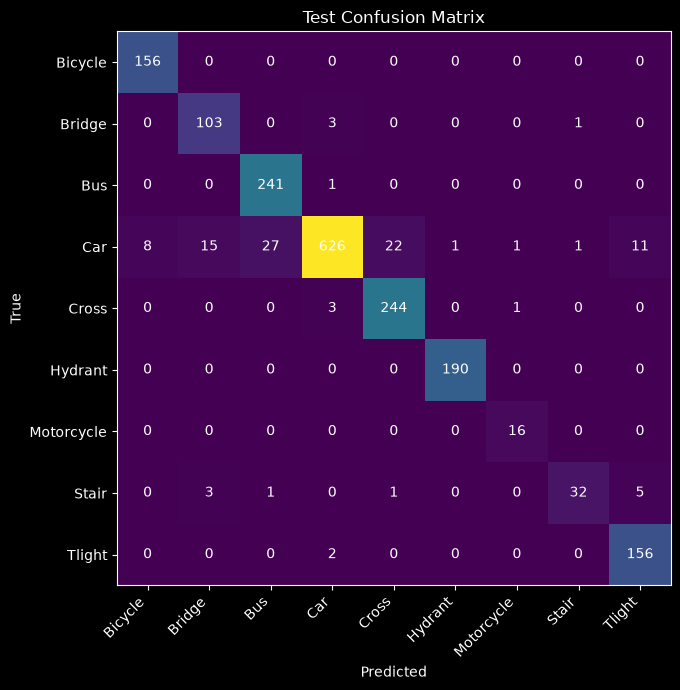

,image_path,true_class,pred_class,confidence,correct
0,C:\Users\Masih\PycharmProjects\captcha\_genera...,Bicycle,Bicycle,0.999844,True
1,C:\Users\Masih\PycharmProjects\captcha\_genera...,Bicycle,Bicycle,0.999671,True
2,C:\Users\Masih\PycharmProjects\captcha\_genera...,Bicycle,Bicycle,0.999667,True
3,C:\Users\Masih\PycharmProjects\captcha\_genera...,Bicycle,Bicycle,0.999762,True
4,C:\Users\Masih\PycharmProjects\captcha\_genera...,Bicycle,Bicycle,0.999735,True


In [7]:
candidate_runs = [p for p in RUNS_DIR.iterdir() if p.is_dir() and (p / "weights" / "best.pt").exists()]
assert candidate_runs, f"No trained model found in: {RUNS_DIR}"

RUN_DIR = max(candidate_runs, key=lambda p: p.stat().st_mtime)
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"

globals().pop("best_model", None)
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

best_model = YOLO(str(BEST_MODEL_PATH))

DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 2
EVAL_IMGSZ = globals().get("IMGSZ", 512)

test_metrics = best_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=EVAL_IMGSZ,
    device=DEVICE,
    workers=WORKERS,
    conf=0.001,
    plots=True,
    save_json=False,
    save_txt=False,
    verbose=True
)

rows = []
img_dir = YOLO_DATASET_DIR / "images" / "test"
lbl_dir = YOLO_DATASET_DIR / "labels" / "test"

for lbl in sorted(lbl_dir.glob("*.txt")):
    img = next(img_dir.glob(f"{lbl.stem}.*"))
    true_id = int(lbl.read_text(encoding="utf-8").split()[0])
    true_class = id_to_class[true_id]

    r = best_model.predict(
        source=str(img),
        imgsz=EVAL_IMGSZ,
        conf=0.001,
        device=DEVICE,
        max_det=5,
        verbose=False
    )[0]

    if r.boxes is None or len(r.boxes) == 0:
        pred_class, conf = "NO_DETECTION", 0.0
    else:
        confs = r.boxes.conf.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy().astype(int)
        j = int(confs.argmax())
        pred_class, conf = best_model.names[int(clss[j])], float(confs[j])

    rows.append({
        "image_path": str(img),
        "true_class": true_class,
        "pred_class": pred_class,
        "confidence": conf,
        "correct": pred_class == true_class
    })

df_all_predictions = pd.DataFrame(rows)

df_test_summary = pd.DataFrame([{
    "test_images": len(df_all_predictions),
    "correct": int(df_all_predictions["correct"].sum()),
    "wrong": int((~df_all_predictions["correct"]).sum()),
    "accuracy": df_all_predictions["correct"].mean()
}])

display(df_test_summary)

report_labels = all_class_names + (
    ["NO_DETECTION"] if "NO_DETECTION" in df_all_predictions["pred_class"].values else []
)

report_df = pd.DataFrame(
    classification_report(
        df_all_predictions["true_class"],
        df_all_predictions["pred_class"],
        labels=report_labels,
        zero_division=0,
        output_dict=True
    )
).T

display(report_df)

cm = confusion_matrix(
    df_all_predictions["true_class"],
    df_all_predictions["pred_class"],
    labels=report_labels
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xticks(range(len(report_labels)), report_labels, rotation=45, ha="right")
plt.yticks(range(len(report_labels)), report_labels)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(report_labels)):
    for j in range(len(report_labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

df_all_predictions.head()

### Cell8 : Show test misclassified samples

,test_images,wrong_predictions,wrong_rate
0,1871,107,0.057189


,true_class,pred_class,count
0,Car,Bus,27
1,Car,Cross,22
2,Car,Bridge,15
3,Car,Tlight,11
4,Car,Bicycle,8
5,Stair,Tlight,5
6,Cross,Car,3
7,Bridge,Car,3
8,Stair,Bridge,3
9,Tlight,Car,2


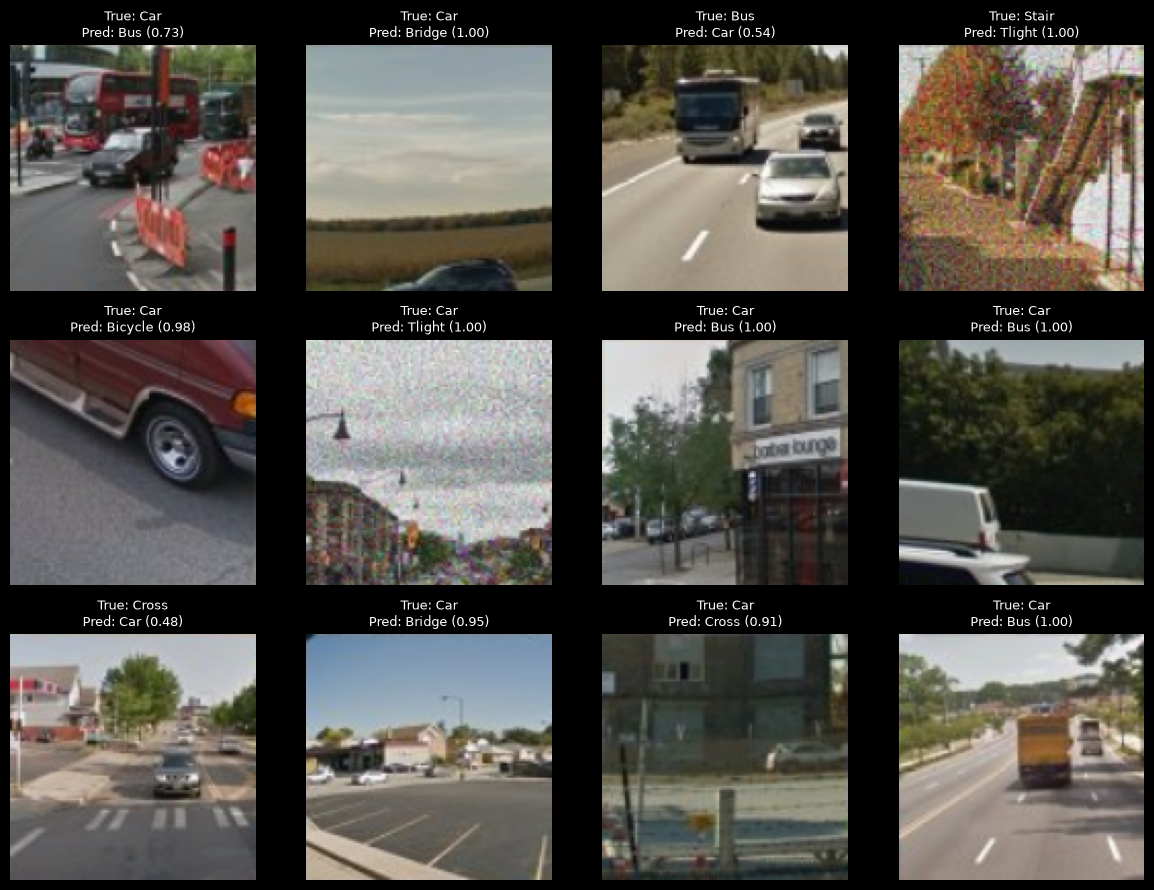

In [8]:
assert "df_all_predictions" in globals(), "Run Cell7 first."
assert len(df_all_predictions) > 0, "df_all_predictions is empty."

wrong_df = df_all_predictions[~df_all_predictions["correct"]].copy()

wrong_summary = pd.DataFrame([{
    "test_images": len(df_all_predictions),
    "wrong_predictions": len(wrong_df),
    "wrong_rate": len(wrong_df) / len(df_all_predictions)
}])

display(wrong_summary)

wrong_pairs = (
    wrong_df.groupby(["true_class", "pred_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(wrong_pairs.head(20))

if len(wrong_df) == 0:
    print("No wrong predictions found.")
else:
    sample_wrong = wrong_df.sample(min(12, len(wrong_df)), random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(12, 9))

    for i, row in sample_wrong.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"True: {row['true_class']}\nPred: {row['pred_class']} ({row['confidence']:.2f})", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Cell9 : Auto solve local HTML

In [9]:
assert HTML_PATH.exists()
assert RUNS_DIR.exists()

candidate_runs = [p for p in RUNS_DIR.iterdir() if p.is_dir() and (p / "weights" / "best.pt").exists()]
assert candidate_runs, f"No trained model found in: {RUNS_DIR}"

RUN_DIR = max(candidate_runs, key=lambda p: p.stat().st_mtime)
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"

globals().pop("best_model", None)
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

best_model = YOLO(str(BEST_MODEL_PATH))

DEVICE = 0 if torch.cuda.is_available() else "cpu"
INFER_IMGSZ = globals().get("IMGSZ", 384)

PREDICT_CONF = 0.001
CLICK_CONF = 0.50
MIN_CONF_MARGIN = 0.08
ROUNDS_TO_RUN = 100
CLICK_DELAY = 0.25
BEFORE_CHECK_DELAY = 2
AFTER_CHECK_DELAY = 3
AFTER_RESET_DELAY = 1

os.environ["NO_PROXY"] = "127.0.0.1,localhost,::1"
os.environ["no_proxy"] = "127.0.0.1,localhost,::1"

CHROME_PATH = next((p for p in [
    r"C:\Program Files\Google\Chrome\Application\chrome.exe",
    r"C:\Program Files (x86)\Google\Chrome\Application\chrome.exe",
    r"C:\Program Files\Microsoft\Edge\Application\msedge.exe",
    r"C:\Program Files (x86)\Microsoft\Edge\Application\msedge.exe",
] if Path(p).exists()), "chrome")

BASE_URL = HTML_PATH.resolve().as_uri()


def get_free_port():
    s = socket.socket()
    s.bind(("127.0.0.1", 0))
    port = s.getsockname()[1]
    s.close()
    return port


def open_browser_with_cdp():
    global browser_process, browser_profile_dir
    port = get_free_port()
    browser_profile_dir = tempfile.mkdtemp(prefix="captcha_cdp_")
    browser_process = subprocess.Popen([
        CHROME_PATH,
        "--remote-debugging-address=127.0.0.1",
        f"--remote-debugging-port={port}",
        f"--user-data-dir={browser_profile_dir}",
        "--remote-allow-origins=*",
        "--no-first-run",
        "--no-default-browser-check",
        "--disable-popup-blocking",
        "--disable-extensions",
        "--new-window",
        BASE_URL,
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(1)
    if browser_process.poll() is not None:
        raise RuntimeError("Chrome/Edge did not start.")
    return port


def wait_for_tabs(port, timeout=30):
    session = requests.Session()
    session.trust_env = False
    url = f"http://127.0.0.1:{port}/json"
    start = time.time()
    while time.time() - start < timeout:
        try:
            r = session.get(url, timeout=2)
            if r.status_code == 200 and r.text.strip().startswith("["):
                tabs = r.json()
                if tabs:
                    return tabs
        except Exception:
            pass
        time.sleep(0.5)
    raise RuntimeError("CDP connection failed.")


def cdp(method, params=None):
    global _cdp_id, cdp_ws
    _cdp_id += 1
    cdp_ws.send(json.dumps({"id": _cdp_id, "method": method, "params": params or {}}))
    while True:
        response = json.loads(cdp_ws.recv())
        if response.get("id") == _cdp_id:
            if "error" in response:
                raise RuntimeError(response["error"])
            return response.get("result", {})


def js_eval(expression):
    return cdp("Runtime.evaluate", {
        "expression": expression,
        "returnByValue": True,
        "awaitPromise": True,
    })["result"].get("value")


def connect_to_page():
    global DEBUG_PORT, cdp_ws, _cdp_id
    try:
        tabs = wait_for_tabs(DEBUG_PORT, timeout=3)
    except Exception:
        DEBUG_PORT = open_browser_with_cdp()
        tabs = wait_for_tabs(DEBUG_PORT, timeout=30)

    page_tab = next((t for t in tabs if t.get("type") == "page" and "website.html" in t.get("url", "")), None)
    page_tab = page_tab or next((t for t in tabs if t.get("type") == "page"), None)

    if page_tab is None:
        raise RuntimeError("No page tab found.")

    cdp_ws = websocket.create_connection(page_tab["webSocketDebuggerUrl"], timeout=10, http_proxy_host=None,
                                         http_proxy_port=None)
    _cdp_id = 0

    for m in ["Page.enable", "Runtime.enable", "DOM.enable", "Page.bringToFront"]:
        cdp(m)

    if "website.html" not in js_eval("location.href"):
        cdp("Page.navigate", {"url": BASE_URL})
        time.sleep(1)


def get_rect(js_expr):
    return js_eval(f"""
    (() => {{
        const el = {js_expr};
        if (!el) return null;
        const r = el.getBoundingClientRect();
        return {{x:r.x,y:r.y,width:r.width,height:r.height,cx:r.x+r.width/2,cy:r.y+r.height/2}};
    }})()
    """)


def screenshot_element(rect):
    result = cdp("Page.captureScreenshot", {
        "format": "png",
        "captureBeyondViewport": True,
        "clip": {"x": rect["x"], "y": rect["y"], "width": rect["width"], "height": rect["height"], "scale": 1},
    })
    return Image.open(io.BytesIO(base64.b64decode(result["data"]))).convert("RGB")


def wait_until_images_loaded(timeout=10):
    start = time.time()
    while time.time() - start < timeout:
        ok = js_eval("""
        (() => {
            const imgs = Array.from(document.querySelectorAll('.tile img'));
            return imgs.length === 9 && imgs.every(img => img.complete && img.naturalWidth > 0);
        })()
        """)
        if ok:
            return True
        time.sleep(0.2)
    return False


def normalize_class_name(x):
    x = str(x).strip().lower().replace(" ", "").replace("_", "").replace("-", "")
    return {"trafficlight": "tlight", "crosswalk": "cross"}.get(x, x)


def same_class(a, b):
    return normalize_class_name(a) == normalize_class_name(b)


def predict_tile(tile_img):
    r = \
    best_model.predict(source=tile_img, imgsz=INFER_IMGSZ, conf=PREDICT_CONF, device=DEVICE, max_det=5, verbose=False)[
        0]
    if r.boxes is None or len(r.boxes) == 0:
        return "NO_DETECTION", 0.0, 0.0
    confs = r.boxes.conf.cpu().numpy()
    clss = r.boxes.cls.cpu().numpy().astype(int)
    order = confs.argsort()[::-1]
    pred_class = best_model.names[int(clss[int(order[0])])]
    pred_conf = float(confs[int(order[0])])
    second_conf = float(confs[int(order[1])]) if len(order) > 1 else 0.0
    return pred_class, pred_conf, pred_conf - second_conf


def clear_tile_labels():
    js_eval("document.querySelectorAll('.ai-mini-label').forEach(el => el.remove())")

def mouse_click(x, y):
    cdp("Input.dispatchMouseEvent", {"type": "mousePressed", "x": x, "y": y, "button": "left", "clickCount": 1})
    cdp("Input.dispatchMouseEvent", {"type": "mouseReleased", "x": x, "y": y, "button": "left", "clickCount": 1})


def solve_one_round(round_id):
    clear_tile_labels()
    wait_until_images_loaded()

    target = js_eval("document.querySelector('#targetName')?.innerText?.trim()")
    tile_rows, selected_tiles = [], []

    for i in range(9):
        img_rect = get_rect(f"document.querySelectorAll('.tile')[{i}].querySelector('img')")
        tile_rect = get_rect(f"document.querySelectorAll('.tile')[{i}]")
        pred_class, pred_conf, margin = predict_tile(screenshot_element(img_rect))

        should_click = same_class(pred_class, target) and pred_conf >= CLICK_CONF and margin >= MIN_CONF_MARGIN

        if should_click:
            mouse_click(tile_rect["cx"], tile_rect["cy"])
            selected_tiles.append(i + 1)
            time.sleep(CLICK_DELAY)

        tile_rows.append({
            "round": round_id,
            "tile": i + 1,
            "target": target,
            "prediction": pred_class,
            "confidence": pred_conf,
            "margin": margin,
            "clicked": should_click
        })

    time.sleep(BEFORE_CHECK_DELAY)
    check_rect = get_rect("document.querySelector('#checkBtn')")
    mouse_click(check_rect["cx"], check_rect["cy"])
    time.sleep(AFTER_CHECK_DELAY)

    status = js_eval("document.querySelector('#status')?.innerText?.trim()")

    return {
        "round": round_id,
        "target": target,
        "selected_tiles": selected_tiles,
        "status": status,
        "correct": str(status).strip() == "Correct."
    }, tile_rows


connect_to_page()
time.sleep(10)
round_results, tile_prediction_rows = [], []

for round_id in range(1, ROUNDS_TO_RUN + 1):
    result, tile_rows = solve_one_round(round_id)
    round_results.append(result)
    tile_prediction_rows.extend(tile_rows)

    if round_id < ROUNDS_TO_RUN:
        reset_rect = get_rect("document.querySelector('#resetBtn')")
        mouse_click(reset_rect["cx"], reset_rect["cy"])
        time.sleep(AFTER_RESET_DELAY)

df_round_results = pd.DataFrame(round_results)
df_tile_predictions = pd.DataFrame(tile_prediction_rows)

display(pd.DataFrame([{
    "rounds": len(df_round_results),
    "correct_rounds": int(df_round_results["correct"].sum()),
    "wrong_rounds": int((~df_round_results["correct"]).sum()),
    "html_success_rate": df_round_results["correct"].mean()
}]))

df_round_results

,rounds,correct_rounds,wrong_rounds,html_success_rate
0,100,100,0,1.0


,round,target,selected_tiles,status,correct
0,1,Bridge,"[5, 6]",Correct.,True
1,2,Tlight,"[2, 3, 5, 6]",Correct.,True
2,3,Car,"[3, 5, 6, 7]",Correct.,True
3,4,Hydrant,"[4, 5, 6]",Correct.,True
4,5,Bridge,"[3, 9]",Correct.,True
...,...,...,...,...,...
95,96,Cross,"[1, 4]",Correct.,True
96,97,Bicycle,"[4, 5]",Correct.,True
97,98,Bicycle,"[2, 3, 7, 9]",Correct.,True
98,99,Bicycle,"[2, 6, 7]",Correct.,True
